In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.svm import LinearSVC
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv(r"C:\Users\Toqa Mohamed Fathy\OneDrive - New Ismailia National University\Documents\3rd year\NLP\Arabic_resturant_reviews_with_6emotions.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,review,label,emotion_extended
0,المطعم يجنن والاكل تحفة,1,joy
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,1,joy
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,0,sadness
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,0,sadness
4,الطعام في هذا المطعم كان سيئًا للغاية والخدمة ...,0,sadness


In [3]:
df=df[[ 'review','emotion_extended']]

# PREPROCESSING

# Arabic text cleaning

In [4]:
def CleanArabicText(text):

    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[A-Za-z0-9]', '', text)
    text = re.sub(r'[^ء-ي\s]', ' ', text)
    text = text.strip()

    # Normalize Arabic letters
    text = re.sub("أ", "ا", text)
    text = re.sub("إ", "ا", text)
    text = re.sub("آ", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["clean_text"] = df["review"].apply(CleanArabicText)

print("Text cleaning completed!")
df[["review", "clean_text", "emotion_extended"]].head()

Text cleaning completed!


,review,clean_text,emotion_extended
0,المطعم يجنن والاكل تحفة,المطعم يجنن والاكل تحفه,joy
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,انصح بزياره المطعم ده بجد الاكل عندهم لذيذ وال...,joy
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,لقد كانت تجربه سيئه الطعام غير مقبول والخدمه س...,sadness
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,الطاقم غير احترافي علي الاطلاق والخدمه بطيئه و...,sadness
4,الطعام في هذا المطعم كان سيئًا للغاية والخدمة ...,الطعام في هذا المطعم كان سيئا للغايه والخدمه ك...,sadness


# TOKENISATION + REMOVE STOPWORDS

In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stopwords_ar = stopwords.words('arabic')
negation_words = ["لا", "ليس", "لم", "لن", "غير", "بدون", "ما", "مش"]


def tokenize_remove_stop(text):
    tokens = word_tokenize(text)
    tokens = [
        w for w in tokens or w in negation_words
        if (w not in stopwords_ar) 
    ]
    return " ".join(tokens)

df['clean_text'] = df['clean_text'].apply(tokenize_remove_stop)
df[["review", "clean_text", "emotion_extended"]].head()


,review,clean_text,emotion_extended
0,المطعم يجنن والاكل تحفة,المطعم يجنن والاكل تحفه,joy
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,انصح بزياره المطعم ده بجد الاكل عندهم لذيذ وال...,joy
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,لقد كانت تجربه سيئه الطعام مقبول والخدمه سيئه ...,sadness
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,الطاقم احترافي علي الاطلاق والخدمه بطيئه وغير ...,sadness
4,الطعام في هذا المطعم كان سيئًا للغاية والخدمة ...,الطعام المطعم سيئا للغايه والخدمه كانت سيئه اي...,sadness


In [9]:
emotion_map = {
    "joy": 0,
    "anger": 1,
    "sadness": 2,
    "disgust": 3,
    "surprise": 4,
    "neutral": 5
}

df["emotion_id"] = df["emotion_extended"].map(emotion_map)

print("Emotion labels encoded successfully!")
df.head()


Emotion labels encoded successfully!


,review,emotion_extended,clean_text,emotion_id
0,المطعم يجنن والاكل تحفة,joy,المطعم يجنن والاكل تحفه,0
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,joy,انصح بزياره المطعم ده بجد الاكل عندهم لذيذ وال...,0
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,sadness,لقد كانت تجربه سيئه الطعام مقبول والخدمه سيئه ...,2
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,sadness,الطاقم احترافي علي الاطلاق والخدمه بطيئه وغير ...,2
4,الطعام في هذا المطعم كان سيئًا للغاية والخدمة ...,sadness,الطعام المطعم سيئا للغايه والخدمه كانت سيئه اي...,2


In [10]:
X = df["clean_text"]
y = df["emotion_id"]


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Dataset split completed!")
print(len(X_train), "training samples")
print(len(X_test), "testing samples")


Dataset split completed!
640 training samples
160 testing samples


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review            800 non-null    object
 1   emotion_extended  800 non-null    object
 2   clean_text        800 non-null    object
 3   emotion_id        800 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.1+ KB


In [12]:
df.describe()

,emotion_id
count,800.000000
mean,0.913750
std,0.979801
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


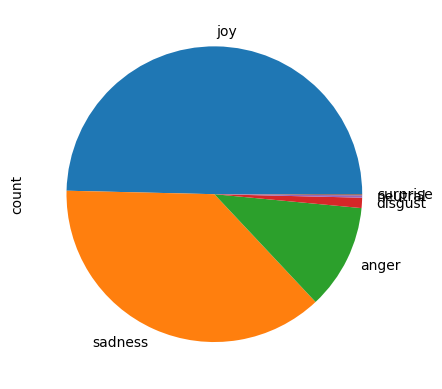

In [13]:
df.emotion_extended.value_counts().plot.pie()
plt.show()

# TF-IDF & LINEAR SVC

In [14]:
vectorizer = TfidfVectorizer(max_features=5000,
                             ngram_range=(1,3),
                             min_df=1,
                             max_df=0.9,)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [15]:
# Convert labels to one-hot
y_train_cat = to_categorical(y_train, num_classes=6)
y_test_cat  = to_categorical(y_test, num_classes=6)


In [16]:
# Keras model
model_tfidf = models.Sequential([
    layers.Input(shape=(X_train_vec.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dense(6, activation="softmax")
])

model_tfidf.compile(
    optimizer="RMSprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_tfidf.fit(
    X_train_vec,
    y_train_cat,
    validation_data=(X_test_vec, y_test_cat),
    epochs=50,
    batch_size=32
)

print("TF-IDF Accuracy:", model_tfidf.evaluate(X_test_vec, y_test_cat)[1])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6234 - loss: 1.6061 - val_accuracy: 0.7875 - val_loss: 1.2789
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7734 - loss: 1.0079 - val_accuracy: 0.8687 - val_loss: 0.6693
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8422 - loss: 0.5561 - val_accuracy: 0.8938 - val_loss: 0.4421
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9141 - loss: 0.3395 - val_accuracy: 0.9125 - val_loss: 0.3677
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9578 - loss: 0.2181 - val_accuracy: 0.9125 - val_loss: 0.3355
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9672 - loss: 0.1442 - val_accuracy: 0.9187 - val_loss: 0.3215
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9734 - loss: 0.1030 - val_accuracy: 0.9312 - val_loss: 0.3135
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9844 - loss: 0.0707 - val_accuracy: 0.9312 - v

In [17]:
y_pred =model_tfidf.predict(X_test_vec)
y_pred_labels = np.argmax(y_pred, axis=1)

results_df = pd.DataFrame({
    "review": X_test.values,       
    "true_emotion": y_test.values,   
    "predicted_emotion": y_pred_labels    
})

results_df.head(10)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,review,true_emotion,predicted_emotion
0,مكان رائع لتناول الطعام الاصدقاء الاكل عندهم ل...,0,0
1,النظافه كانت مساله مستمره يتم تنظيف المطعم بشك...,2,2
2,المكان ده جامد جدا الاكل عندهم مذاقه فشيخ والخ...,0,0
3,الطعام باردا عندما وصل والخدمه كانت سيئه جدا و...,2,2
4,المكان ده كانه فلم هوليودي مستحيل تمر تتذكره,0,0
5,تجربه سيئه جدا المطعم الطعام سيئا للغايه وغير ...,2,2
6,الاكل المطعم ده بيديك شعور بالسكينه والطمانينه...,0,0
7,المطعم ده عنده فن اعداد الطعام لقمه طعم مختلف ...,0,0
8,احببت شيء المطعم الاطباق الي الخدمه,0,0
9,لقد كانت تجربه سيئه جدا الطعام سيء للغايه والخ...,1,1


In [18]:
MAX_WORDS = 20000
MAX_LEN = 80

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN)

In [19]:
# Parameter grid for LinearSVC
param_grid = {
    'C': [0.1, 1, 10 , 100],
    'class_weight': ['balanced', None],
    'max_iter': [2000]
}

# Grid search
grid_search = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=7,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best Cross Validation score:", grid_search.best_score_)

svm_model = grid_search.best_estimator_

c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=7.
  warnings.warn(


Best parameters: {'C': 100, 'class_weight': 'balanced', 'max_iter': 2000}
Best Cross Validation score: 0.962476964029759


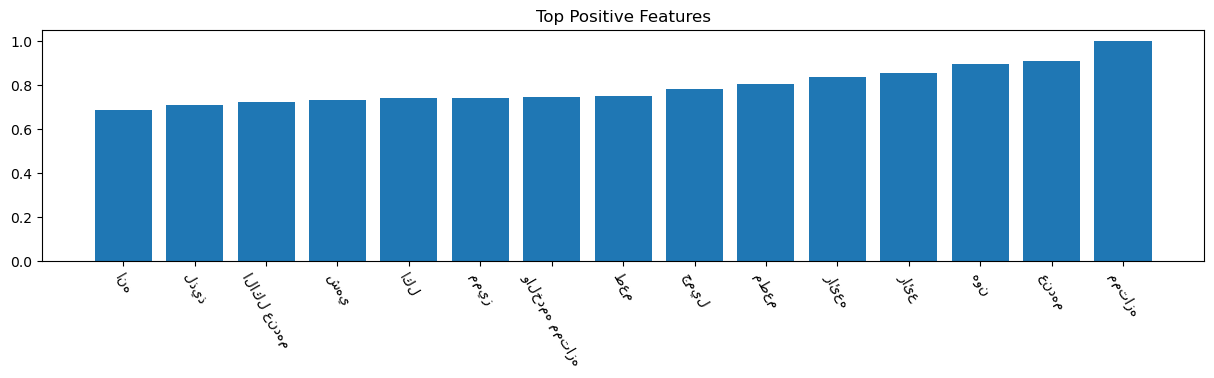

In [20]:

feature_names = vectorizer.get_feature_names_out()
coef = svm_model.coef_[0]

top_pos = np.argsort(coef)[-15:]
plt.figure(figsize=(15,3))
plt.bar(np.array(feature_names)[top_pos], coef[top_pos])
plt.xticks(rotation=300)
plt.title("Top Positive Features")
plt.show()

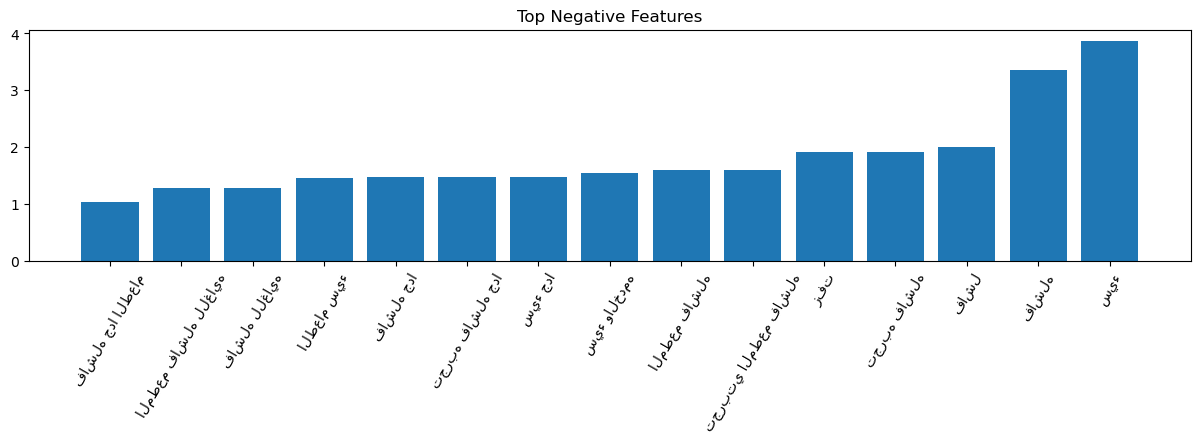

In [21]:
coef = svm_model.coef_[1]

top_neg = np.argsort(coef)[-15:]
plt.figure(figsize=(15,3))
plt.bar(np.array(feature_names)[top_neg], coef[top_neg])
plt.xticks(rotation=60)
plt.title("Top Negative Features")
plt.show()

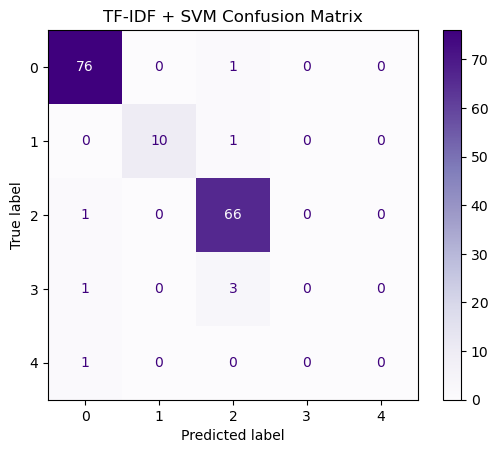

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = svm_model.predict(X_test_vec)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot(cmap='Purples')
plt.title("TF-IDF + SVM Confusion Matrix")
plt.show()

# CNN MODEL


In [23]:
from keras import models, layers, optimizers, callbacks
from keras.regularizers import l2
import numpy as np

model_cnn = models.Sequential([
    layers.Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),
    layers.MaxPooling1D(pool_size=2),

    layers.Dropout(0.4),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),
    layers.GlobalMaxPooling1D(),
    
    # Dropout الثانية المضافة لمكافحة الـ Overfitting
    layers.Dropout(0.3), 
    
    layers.Dense(64, activation="relu", kernel_regularizer=l2(0.01)),
    layers.Dense(6, activation="softmax")
])

optimizer = optimizers.RMSprop(learning_rate=0.0005)

model_cnn.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping (لم يتم استخدامه في الكود الأصلي، لكن تعريفه صحيح)
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

# 2. تعديل ReduceLROnPlateau: زيادة patience
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=7, # تم زيادتها من 5 إلى 7 
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# 3. تعديل Callbacks: إضافة early_stop لضمان استعادة أفضل الأوزان
my_callbacks = [early_stop, reduce_lr, checkpoint]

c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
historyt = model_cnn.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=40,
    batch_size=64,
    callbacks=my_callbacks
)
print("CNN Accuracy:", model_cnn.evaluate(X_test_pad, np.array(y_test))[1])


Epoch 1/40


 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2749 - loss: 2.3545
Epoch 1: val_loss improved from None to 1.91714, saving model to best_cnn_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.3859 - loss: 2.1900 - val_accuracy: 0.4812 - val_loss: 1.9171 - learning_rate: 5.0000e-04
Epoch 2/40
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4727 - loss: 1.7599
Epoch 2: val_loss improved from 1.91714 to 1.68246, saving model to best_cnn_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4969 - loss: 1.6817 - val_accuracy: 0.4812 - val_loss: 1.6825 - learning_rate: 5.0000e-04
Epoch 3/40
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4823 - loss: 1.6473
Epoch 3: val_loss improved from 1.68246 to 1.65345, saving model to best_cnn_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4688 - loss: 1.6242 - val_accuracy: 0.4875 - val_loss: 1.6535 - learning_rate: 5.0000e-04
Epoch 4/40
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accura

In [25]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# Get predictions from the CNN model
predictions = model_cnn.predict(X_test_pad)
all_preds = np.argmax(predictions, axis=1)

# Get true labels
all_labels = y_test.to_numpy()

print("CNN Test Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
CNN Test Accuracy: 0.93125
              precision    recall  f1-score   support

           0     0.9737    0.9610    0.9673        77
           1     0.6429    0.8182    0.7200        11
           2     0.9429    0.9851    0.9635        67
           3     0.0000    0.0000    0.0000         4
           5     0.0000    0.0000    0.0000         1

    accuracy                         0.9313       160
   macro avg     0.5119    0.5529    0.5302       160
weighted avg     0.9076    0.9313    0.9185       160

Confusion Matrix:
 [[74  3  0  0  0]
 [ 1  9  1  0  0]
 [ 0  1 66  0  0]
 [ 0  1  3  0  0]
 [ 1  0  0  0  0]]


c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

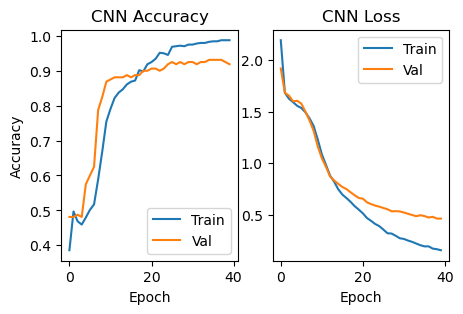

In [26]:
import matplotlib.pyplot as plt

history = historyt   # your BiLSTM model history variable

plt.figure(figsize=(5,3))

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'])

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'])

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


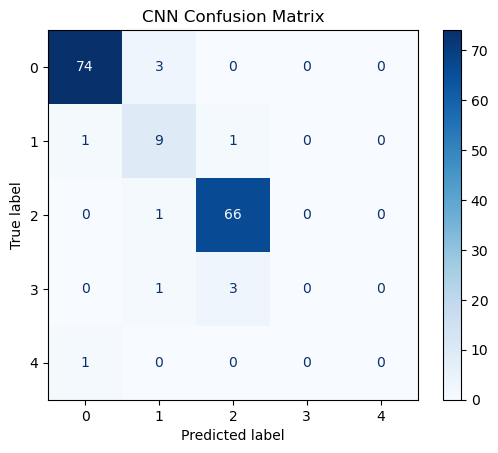

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

predictions_proba = model_cnn.predict(X_test_pad)
pred = np.argmax(predictions_proba, axis=1)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.show()

# EXTRA MODELS AND FEATURES ENGINEERING

# FastText


In [ ]:
import fasttext

def save_fasttext_file(texts, labels, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for text, label in zip(texts, labels):
            clean = text.replace("\n", " ")
            f.write(f"__label__{label} {clean}\n")

# Create training and testing files
save_fasttext_file(X_train, y_train, "ft_train.txt")
save_fasttext_file(X_test, y_test, "ft_test.txt")

In [245]:
model_fasttext = fasttext.train_supervised(
    input="ft_train.txt",
    lr=1,               # learning rate
    dim=100,              # embedding dimension
    epoch=30,             # number of passes
    wordNgrams=2,         # use word n-grams
    loss="softmax"        # softmax classifier
)

print("FastText model trained!")

FastText model trained!


In [247]:
train_result = model_fasttext.test("ft_train.txt")
print("Train Accuracy:", train_result[1])


Train Accuracy: 0.996875


In [249]:
test_result = model_fasttext.test("ft_test.txt")

print("FASTTEXT RESULTS")
print("Total Samples:", test_result[0])
print("Test Accuracy:", test_result[1])
print("F1 Score:", test_result[2])

FASTTEXT RESULTS
Total Samples: 160
Test Accuracy: 0.9625
F1 Score: 0.9625


# BILSTM

In [40]:
from keras.layers import Dense
from keras.regularizers import l2, l1
model_bilstm = models.Sequential([
    layers.Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(128, return_sequences=False, recurrent_dropout=0.2)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=l2(0.01)),
    layers.Dense(6, activation="softmax")
])

optimizer = optimizers.RMSprop(learning_rate=0.0005)

model_bilstm.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=5,
    min_lr=1e-6,
    verbose=1,
    learning_rate=0.0001
)

checkpoint = callbacks.ModelCheckpoint(
    "best_bilstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

my_callbacks = [early_stop, reduce_lr, checkpoint]

history = model_bilstm.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=30,
    batch_size=64,
    callbacks=my_callbacks
)

Epoch 1/30


c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.3930 - loss: 2.5848
Epoch 1: val_loss improved from None to 1.93174, saving model to best_bilstm_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.4203 - loss: 2.3608 - val_accuracy: 0.4812 - val_loss: 1.9317 - learning_rate: 5.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5206 - loss: 1.9209
Epoch 2: val_loss improved from 1.93174 to 1.85853, saving model to best_bilstm_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.4969 - loss: 1.9172 - val_accuracy: 0.4812 - val_loss: 1.8585 - learning_rate: 5.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4814 - loss: 1.8728
Epoch 3: val_loss improved from 1.85853 to 1.82480, saving model to best_bilstm_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.4969 - loss: 1.8285 - val_accuracy: 0.4812 - val_loss: 1.8248 - learning_rate: 5.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 165m

In [41]:
print("BiLSTM Accuracy:", model_bilstm.evaluate(X_test_pad, np.array(y_test))[1])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9062 - loss: 0.5815
BiLSTM Accuracy: 0.90625


In [42]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np # Ensure numpy is imported for argmax

# Get predictions from the BiLSTM model
predictions = model_bilstm.predict(X_test_pad)
all_preds = np.argmax(predictions, axis=1)

# Get true labels
all_labels = y_test.to_numpy() # Convert y_test Series to numpy array

print("BiLSTM Test Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
BiLSTM Test Accuracy: 0.90625
              precision    recall  f1-score   support

           0     0.9620    0.9870    0.9744        77
           1     0.5000    0.6364    0.5600        11
           2     0.9254    0.9254    0.9254        67
           3     0.0000    0.0000    0.0000         4
           5     0.0000    0.0000    0.0000         1

    accuracy                         0.9062       160
   macro avg     0.4775    0.5097    0.4919       160
weighted avg     0.8848    0.9062    0.8949       160

Confusion Matrix:
 [[76  1  0  0  0]
 [ 1  7  3  0  0]
 [ 0  5 62  0  0]
 [ 1  1  2  0  0]
 [ 1  0  0  0  0]]


c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

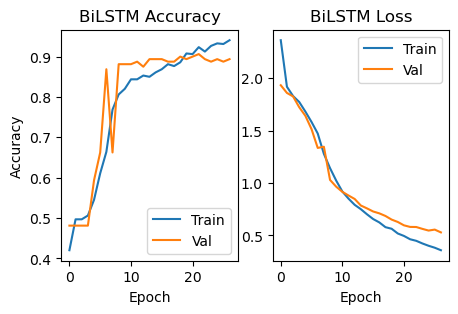

In [43]:
import matplotlib.pyplot as plt

history = history   # your BiLSTM model history variable

plt.figure(figsize=(5,3))

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('BiLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'])

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('BiLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'])

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


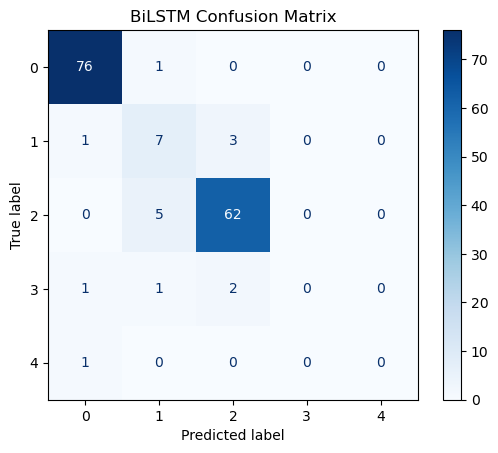

In [44]:
predictions_proba = model_bilstm.predict(X_test_pad)
pred = np.argmax(predictions_proba, axis=1)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("BiLSTM Confusion Matrix")
plt.show()